In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from scipy.stats import kurtosis, ks_2samp

In [2]:
path_with = "/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_WithH_DP.npz"
path_none = "/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_NoneH_DP.npz"

data_with = np.load(path_with)
data_none = np.load(path_none)

x_with = np.asarray(data_with["ampl"], dtype=np.complex64).ravel()
x_none = np.asarray(data_none["ampl"], dtype=np.complex64).ravel()

print("Signal avec DP :", x_with.shape)
print("Signal sans DP :", x_none.shape)

Signal avec DP : (36000000,)
Signal sans DP : (36000000,)


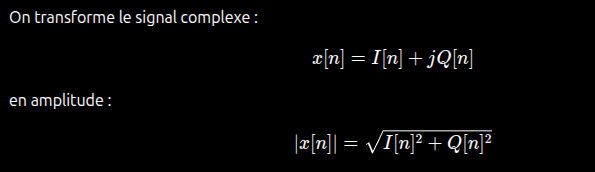

In [3]:
env_with = np.abs(x_with)
env_none = np.abs(x_none)

print("Enveloppe avec DP :", env_with.shape)
print("Enveloppe sans DP :", env_none.shape)

Enveloppe avec DP : (36000000,)
Enveloppe sans DP : (36000000,)


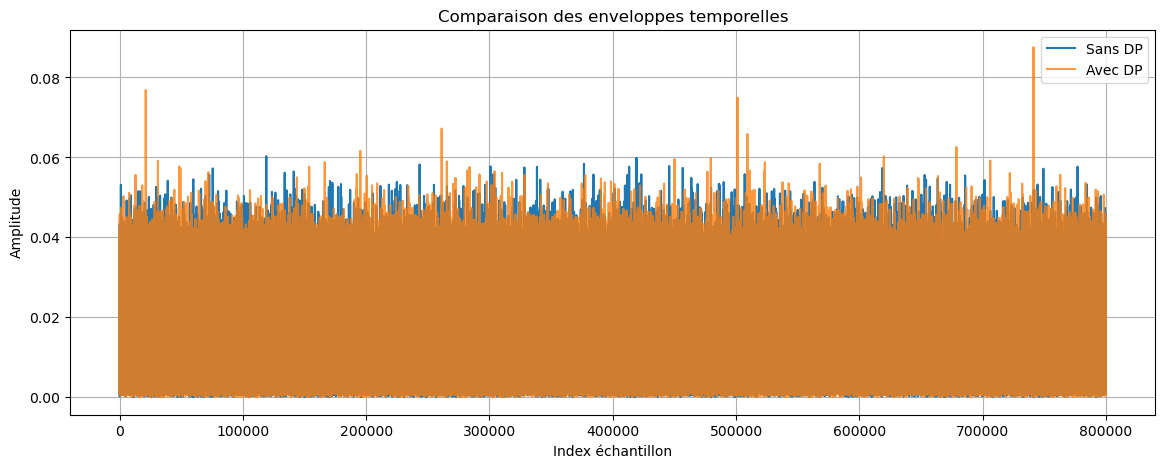

In [4]:
N_plot = 800000

plt.figure(figsize=(14,5))
plt.plot(env_none[:N_plot], label="Sans DP")
plt.plot(env_with[:N_plot], label="Avec DP", alpha=0.8)
plt.title("Comparaison des enveloppes temporelles")
plt.xlabel("Index échantillon")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

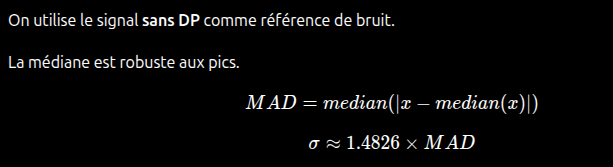

In [5]:
mu_noise = np.median(env_none)

mad_noise = np.median(np.abs(env_none - mu_noise))

sigma_noise = 1.4826 * mad_noise

print("Médiane bruit =", mu_noise)
print("MAD bruit =", mad_noise)
print("Sigma robuste bruit =", sigma_noise)

Médiane bruit = 0.014299148
MAD bruit = 0.005446204
Sigma robuste bruit = 0.008074542027153074


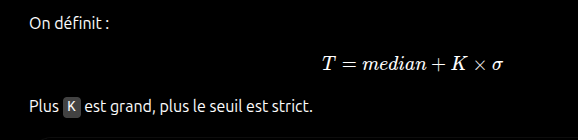

In [6]:
K = 8

threshold = mu_noise + K * sigma_noise

print("Seuil de détection =", threshold)

Seuil de détection = 0.07889548397958278


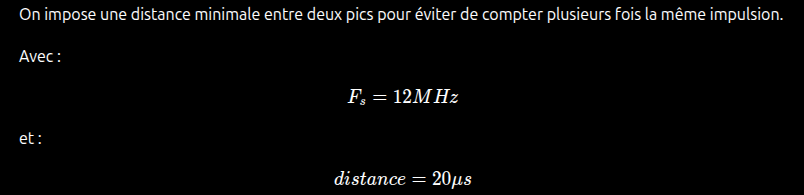

In [7]:
FS = 12e6

min_distance_us = 20
min_distance_samples = int(min_distance_us * 1e-6 * FS)

peaks_none, props_none = find_peaks(
    env_none,
    height=threshold,
    distance=min_distance_samples
)

peaks_with, props_with = find_peaks(
    env_with,
    height=threshold,
    distance=min_distance_samples
)

print("Nombre de pics sans DP :", len(peaks_none))
print("Nombre de pics avec DP :", len(peaks_with))

Nombre de pics sans DP : 0
Nombre de pics avec DP : 97


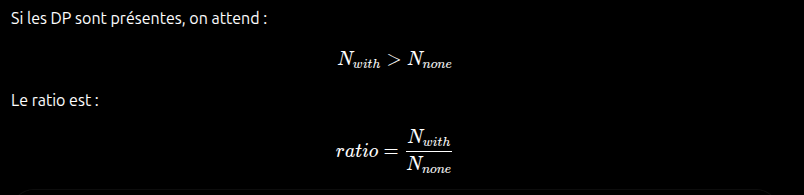

In [8]:
ratio_peaks = len(peaks_with) / max(len(peaks_none), 1)

print("Ratio pics avec/sans =", ratio_peaks)

if ratio_peaks > 2:
    print("Le signal avec DP contient beaucoup plus d'impulsions.")
else:
    print("Pas de forte augmentation du nombre d'impulsions.")

Ratio pics avec/sans = 97.0
Le signal avec DP contient beaucoup plus d'impulsions.


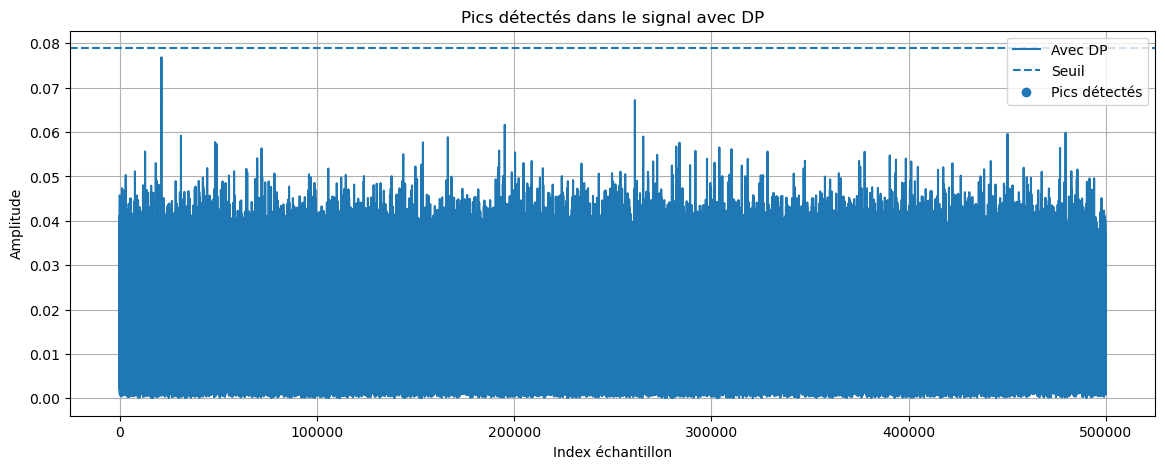

In [9]:
N_plot = 500000

plt.figure(figsize=(14,5))
plt.plot(env_with[:N_plot], label="Avec DP")
plt.axhline(threshold, linestyle="--", label="Seuil")

valid_peaks_with = peaks_with[peaks_with < N_plot]
plt.scatter(
    valid_peaks_with,
    env_with[valid_peaks_with],
    label="Pics détectés"
)

plt.title("Pics détectés dans le signal avec DP")
plt.xlabel("Index échantillon")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

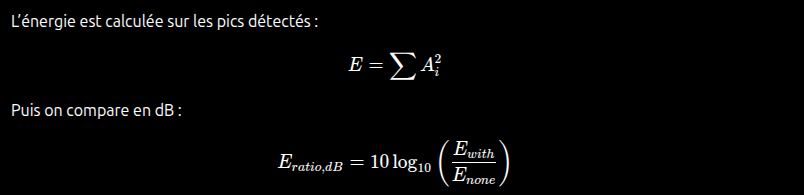

In [10]:
E_none = np.sum(env_none[peaks_none] ** 2)
E_with = np.sum(env_with[peaks_with] ** 2)

E_ratio_db = 10 * np.log10((E_with + 1e-20) / (E_none + 1e-20))

print("Énergie impulsionnelle sans DP =", E_none)
print("Énergie impulsionnelle avec DP =", E_with)
print("Gain énergie impulsionnelle =", E_ratio_db, "dB")

print("\n")

if E_ratio_db > 3:
    print("L'énergie impulsionnelle est significativement plus grande avec DP.")
else:
    print("Pas de forte augmentation de l'énergie impulsionnelle.")

Énergie impulsionnelle sans DP = 0.0
Énergie impulsionnelle avec DP = 0.84751457
Gain énergie impulsionnelle = 199.2814717296563 dB


L'énergie impulsionnelle est significativement plus grande avec DP.


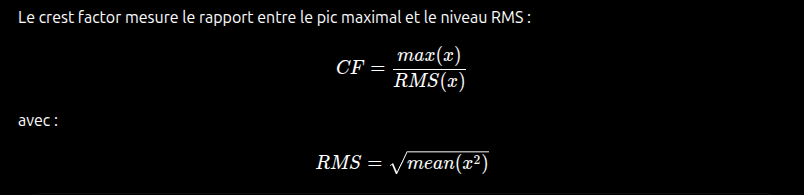

In [11]:
cf_none = np.max(env_none) / np.sqrt(np.mean(env_none ** 2))
cf_with = np.max(env_with) / np.sqrt(np.mean(env_with ** 2))

cf_none_db = 20 * np.log10(cf_none)
cf_with_db = 20 * np.log10(cf_with)

cf_diff_db = cf_with_db - cf_none_db

print("Crest factor sans DP =", cf_none_db, "dB")
print("Crest factor avec DP =", cf_with_db, "dB")
print("Différence crest factor =", cf_diff_db, "dB")

print("\n")

if cf_diff_db > 3:
    print("Le signal avec DP contient des amplitudes extrêmes plus fortes.")
else:
    print("Pas de forte augmentation des amplitudes extrêmes.")

Crest factor sans DP = 12.756651639938354 dB
Crest factor avec DP = 17.082045078277588 dB
Différence crest factor = 4.325393438339233 dB


Le signal avec DP contient des amplitudes extrêmes plus fortes.


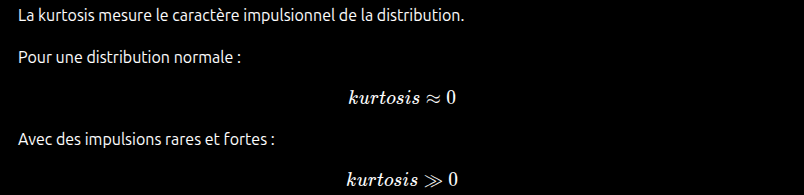

In [12]:
k_none = kurtosis(env_none, fisher=True)
k_with = kurtosis(env_with, fisher=True)

k_diff = k_with - k_none

print("Kurtosis sans DP =", k_none)
print("Kurtosis avec DP =", k_with)
print("Différence kurtosis =", k_diff)

print("\n")

if k_with > 1.5 * k_none:
    print("La distribution avec DP est beaucoup plus impulsionnelle.")
else:
    print("Pas de forte augmentation de l'impulsivité.")

Kurtosis sans DP = 0.2469754266151032
Kurtosis avec DP = 0.279791078700792
Différence kurtosis = 0.03281565208568882


Pas de forte augmentation de l'impulsivité.


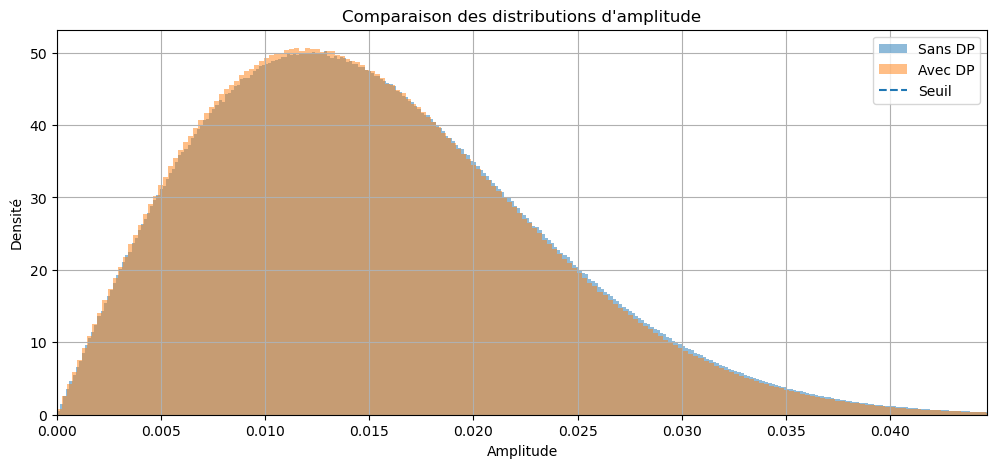

In [13]:
plt.figure(figsize=(12,5))

plt.hist(env_none, bins=500, density=True, alpha=0.5, label="Sans DP")
plt.hist(env_with, bins=500, density=True, alpha=0.5, label="Avec DP")

plt.axvline(threshold, linestyle="--", label="Seuil")

plt.xlim(0, np.percentile(env_with, 99.9))
plt.title("Comparaison des distributions d'amplitude")
plt.xlabel("Amplitude")
plt.ylabel("Densité")
plt.grid(True)
plt.legend()
plt.show()

In [14]:
score = 0

if ratio_peaks > 2:
    score += 35

if E_ratio_db > 3:
    score += 30

if cf_diff_db > 3:
    score += 20

if k_with > 1.5 * k_none:
    score += 15

score = min(score, 100)

print("Score présence DP =", score, "%")

Score présence DP = 85 %


In [18]:
print("===== Résumé =====")
print("Ratio pics avec/sans =", ratio_peaks)
print("Gain énergie impulsionnelle =", E_ratio_db, "dB")
print("Différence crest factor =", cf_diff_db, "dB")
print("Kurtosis sans DP =", k_none)
print("Kurtosis avec DP =", k_with)
print("Score DP =", score, "%")

===== Résumé =====
Ratio pics avec/sans = 97.0
Gain énergie impulsionnelle = 199.2814717296563 dB
Différence crest factor = 4.325393438339233 dB
Kurtosis sans DP = 0.2469754266151032
Kurtosis avec DP = 0.279791078700792
Score DP = 85 %


Signal avec DP : (36000000,)
Signal sans DP : (36000000,)

===== Résultats Wavelet =====

Niveau A5
  Energie sans DP      = 1.5780e+06
  Energie avec DP      = 1.3885e+06
  Ratio énergie        = -0.56 dB
  Kurtosis sans DP     = 0.0112
  Kurtosis avec DP     = 0.0076
  Différence kurtosis  = -0.0036

Niveau D5
  Energie sans DP      = 1.1042e+06
  Energie avec DP      = 1.0804e+06
  Ratio énergie        = -0.09 dB
  Kurtosis sans DP     = 0.0080
  Kurtosis avec DP     = 0.0225
  Différence kurtosis  = 0.0145

Niveau D4
  Energie sans DP      = 2.2020e+06
  Energie avec DP      = 2.1494e+06
  Ratio énergie        = -0.10 dB
  Kurtosis sans DP     = 0.0129
  Kurtosis avec DP     = 0.0189
  Différence kurtosis  = 0.0060

Niveau D3
  Energie sans DP      = 4.3813e+06
  Energie avec DP      = 4.2703e+06
  Ratio énergie        = -0.11 dB
  Kurtosis sans DP     = 0.0308
  Kurtosis avec DP     = 0.0406
  Différence kurtosis  = 0.0098

Niveau D2
  Energie sans DP      = 8.7419e+06
  Energie a

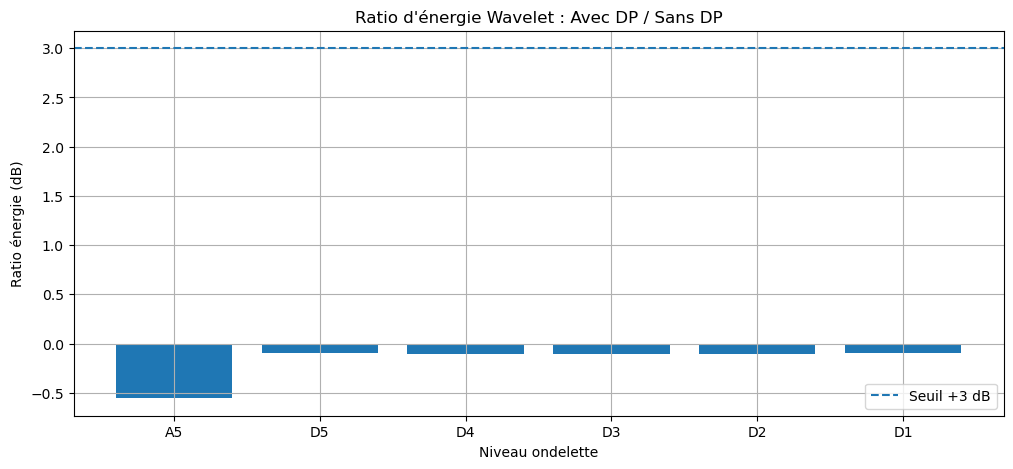

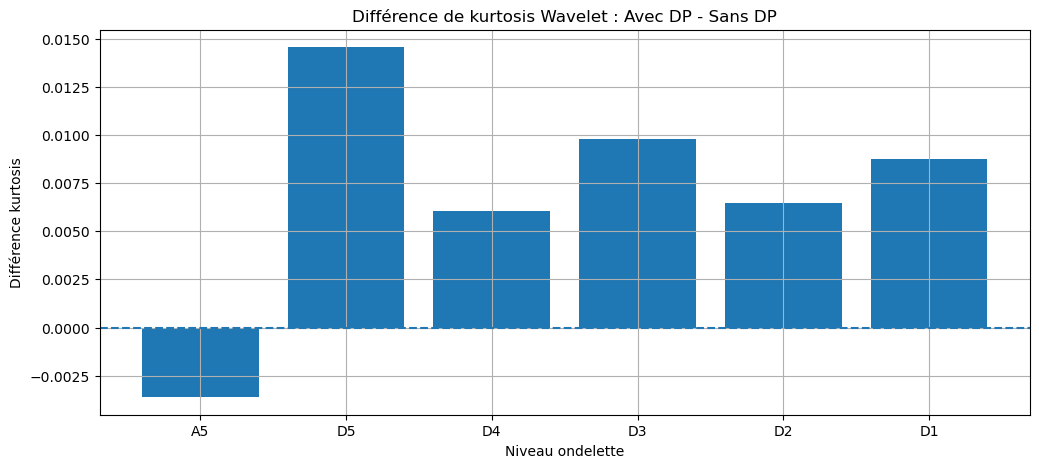

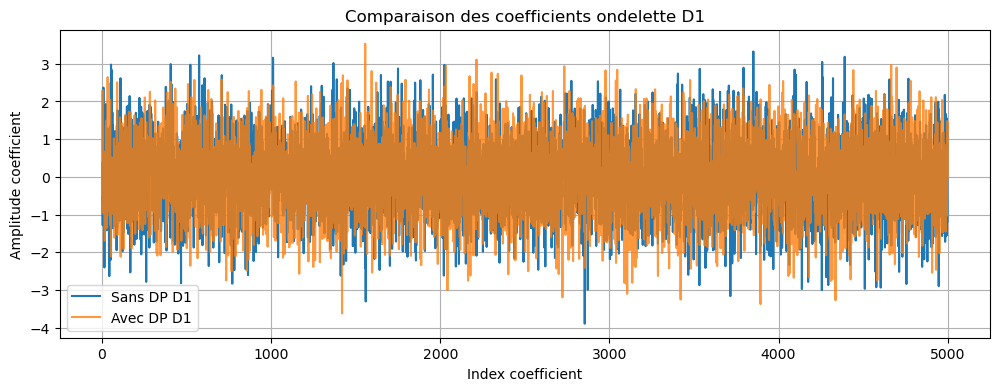

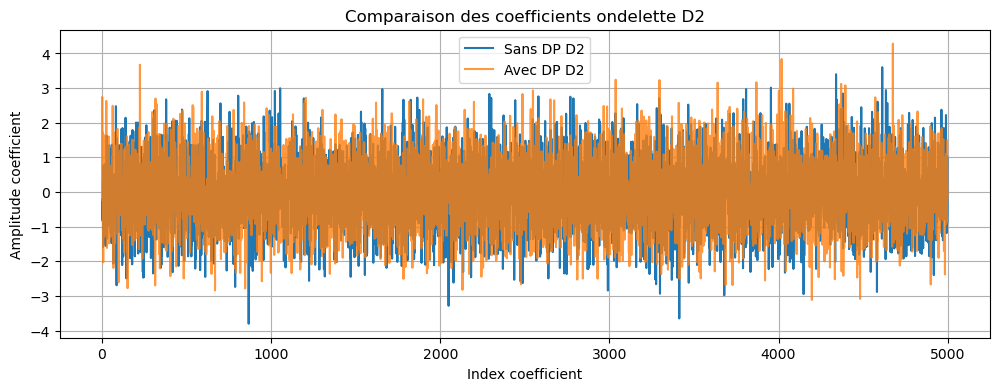

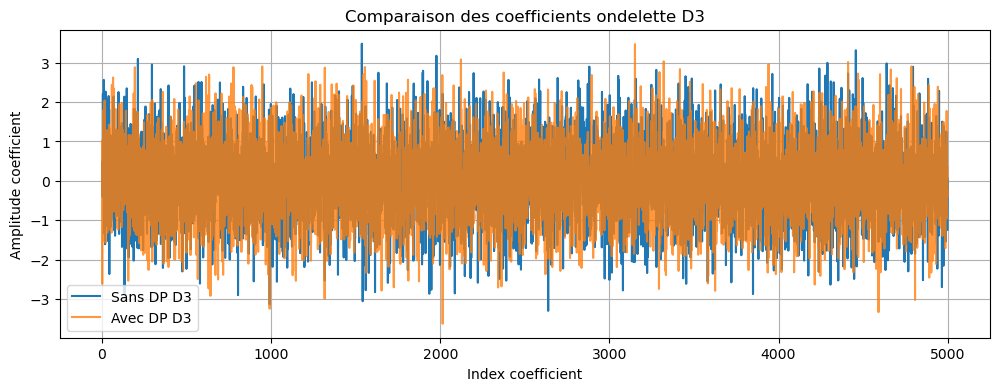

In [43]:
# ============================================================
# Analyse Wavelet DWT pour comparer signal Avec DP / Sans DP
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

# Si PyWavelets n'est pas installé :
# !pip install PyWavelets

import pywt


# =========================
# 1) Charger les signaux
# =========================

path_with = "/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_WithH_DP.npz"
path_none = "/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_NoneH_DP.npz"

data_with = np.load(path_with)
data_none = np.load(path_none)

x_with = np.asarray(data_with["ampl"], dtype=np.complex64).ravel()
x_none = np.asarray(data_none["ampl"], dtype=np.complex64).ravel()

print("Signal avec DP :", x_with.shape)
print("Signal sans DP :", x_none.shape)


# =========================
# 2) Enveloppe amplitude
# =========================
# x[n] = I[n] + jQ[n]
# env[n] = |x[n]| = sqrt(I[n]^2 + Q[n]^2)

env_with = np.abs(x_with)
env_none = np.abs(x_none)


# Optionnel : normalisation robuste pour comparer proprement
# On utilise le signal sans DP comme référence de bruit

mu_noise = np.median(env_none)
mad_noise = np.median(np.abs(env_none - mu_noise))
sigma_noise = 1.4826 * mad_noise + 1e-20

env_with_n = (env_with - mu_noise) / sigma_noise
env_none_n = (env_none - mu_noise) / sigma_noise


# =========================
# 3) Décomposition Wavelet
# =========================
# db4 : Daubechies 4, souvent utilisée pour les signaux impulsionnels
# level=5 : séparation du signal en plusieurs bandes de détails

wavelet_name = "db4"
level = 5

coeffs_with = pywt.wavedec(env_with_n, wavelet_name, level=level)
coeffs_none = pywt.wavedec(env_none_n, wavelet_name, level=level)

# Structure :
# coeffs = [A5, D5, D4, D3, D2, D1]
# A5 = approximation basse fréquence
# D1 = détails haute fréquence
# D2, D3... = détails de plus en plus basse fréquence

labels = ["A5", "D5", "D4", "D3", "D2", "D1"]


# =========================
# 4) Énergie par niveau
# =========================
# Energie = somme des carrés des coefficients
# Une DP augmente souvent l'énergie dans les détails D1, D2, D3

energy_with = np.array([np.sum(c**2) for c in coeffs_with])
energy_none = np.array([np.sum(c**2) for c in coeffs_none])

energy_ratio_db = 10 * np.log10((energy_with + 1e-20) / (energy_none + 1e-20))


# =========================
# 5) Kurtosis par niveau
# =========================
# Kurtosis élevée = coefficients très impulsionnels
# Une DP produit souvent une forte kurtosis dans D1, D2, D3

kurt_with = np.array([kurtosis(c, fisher=True) for c in coeffs_with])
kurt_none = np.array([kurtosis(c, fisher=True) for c in coeffs_none])

kurt_diff = kurt_with - kurt_none


# =========================
# 6) Affichage des résultats
# =========================

print("\n===== Résultats Wavelet =====")
for i, label in enumerate(labels):
    print(f"\nNiveau {label}")
    print(f"  Energie sans DP      = {energy_none[i]:.4e}")
    print(f"  Energie avec DP      = {energy_with[i]:.4e}")
    print(f"  Ratio énergie        = {energy_ratio_db[i]:.2f} dB")
    print(f"  Kurtosis sans DP     = {kurt_none[i]:.4f}")
    print(f"  Kurtosis avec DP     = {kurt_with[i]:.4f}")
    print(f"  Différence kurtosis  = {kurt_diff[i]:.4f}")


# =========================
# 7) Score simple basé sur D1, D2, D3
# =========================
# D1, D2, D3 sont souvent les plus importants pour les impulsions rapides.

detail_indices = {
    "D1": labels.index("D1"),
    "D2": labels.index("D2"),
    "D3": labels.index("D3"),
}

score = 0

for name, idx in detail_indices.items():
    if energy_ratio_db[idx] > 3:
        score += 15
    if kurt_with[idx] > 1.5 * max(kurt_none[idx], 1e-9):
        score += 15

score = min(score, 100)

print("\n===== Décision Wavelet =====")
print("Score Wavelet DP =", score, "%")

if score >= 60:
    print("Conclusion : DP probable selon l'analyse ondelette.")
elif score >= 30:
    print("Conclusion : présence impulsionnelle possible, à confirmer.")
else:
    print("Conclusion : pas de preuve forte de DP par ondelette.")


# =========================
# 8) Visualisation graphique
# =========================

plt.figure(figsize=(12, 5))
plt.bar(labels, energy_ratio_db)
plt.axhline(3, linestyle="--", label="Seuil +3 dB")
plt.title("Ratio d'énergie Wavelet : Avec DP / Sans DP")
plt.xlabel("Niveau ondelette")
plt.ylabel("Ratio énergie (dB)")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(12, 5))
plt.bar(labels, kurt_diff)
plt.axhline(0, linestyle="--")
plt.title("Différence de kurtosis Wavelet : Avec DP - Sans DP")
plt.xlabel("Niveau ondelette")
plt.ylabel("Différence kurtosis")
plt.grid(True)
plt.show()


# =========================
# 9) Visualisation des coefficients D1, D2, D3
# =========================

for name in ["D1", "D2", "D3"]:
    idx = labels.index(name)

    N_plot = min(5000, len(coeffs_with[idx]), len(coeffs_none[idx]))

    plt.figure(figsize=(12, 4))
    plt.plot(coeffs_none[idx][:N_plot], label=f"Sans DP {name}")
    plt.plot(coeffs_with[idx][:N_plot], label=f"Avec DP {name}", alpha=0.8)
    plt.title(f"Comparaison des coefficients ondelette {name}")
    plt.xlabel("Index coefficient")
    plt.ylabel("Amplitude coefficient")
    plt.grid(True)
    plt.legend()
    plt.show()

In [38]:
idx = labels.index("D3")

D3_with = coeffs_with[idx]
D3_none = coeffs_none[idx]

print(np.max(np.abs(D3_with)))
print(np.max(np.abs(D3_none)))

7.7617397
5.1672997


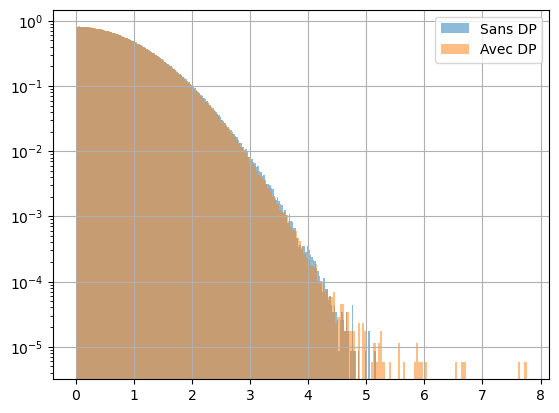

In [39]:
plt.hist(
    np.abs(D3_none),
    bins=200,
    density=True,
    alpha=0.5,
    label="Sans DP"
)

plt.hist(
    np.abs(D3_with),
    bins=200,
    density=True,
    alpha=0.5,
    label="Avec DP"
)

plt.yscale("log")
plt.legend()
plt.grid()
plt.show()

Seuil max detail = 6.294843059158325
Seuil energy detail = 4180.093899609375
Seuil kurtosis detail = 0.7836225161544148

Nombre fenêtres suspectes sans DP : 2
Nombre fenêtres suspectes avec DP : 90
Ratio fenêtres suspectes avec/sans = 45.0


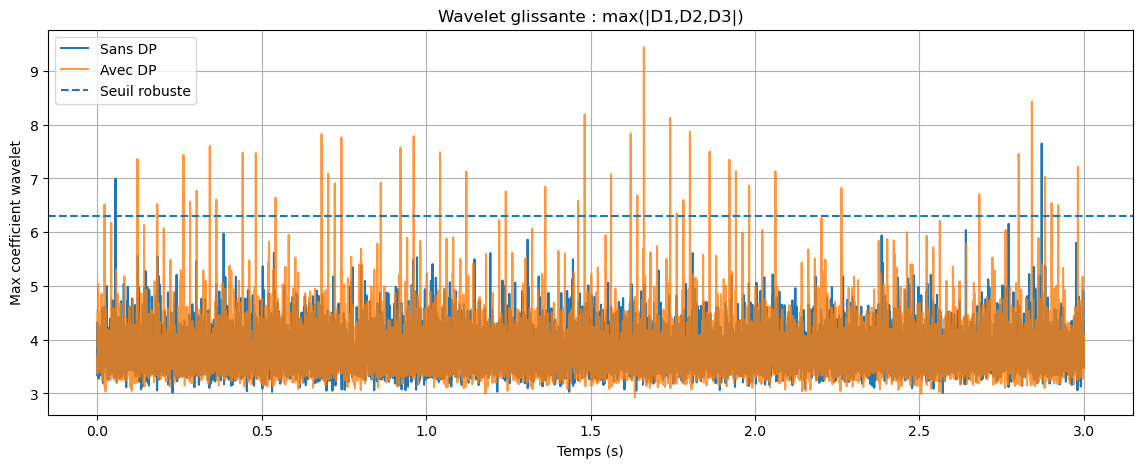

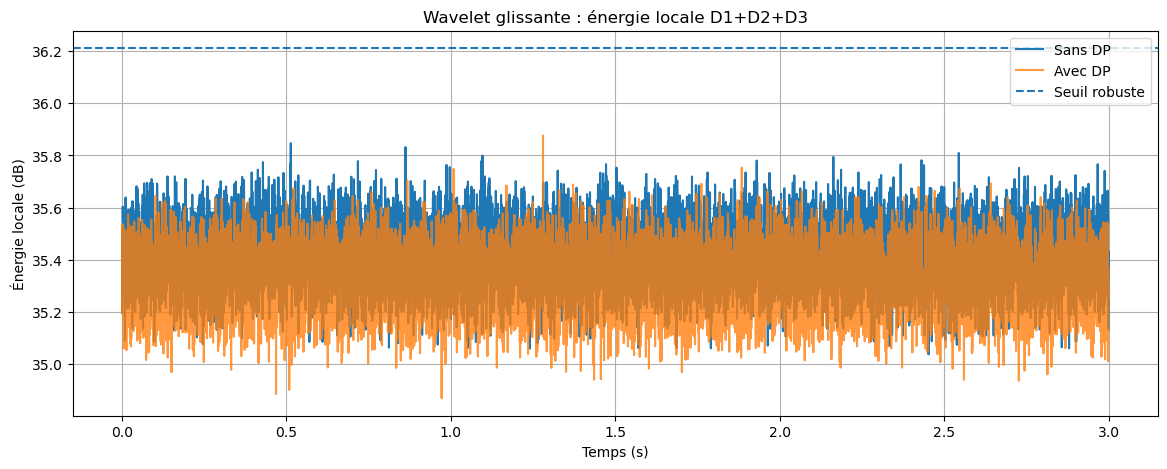

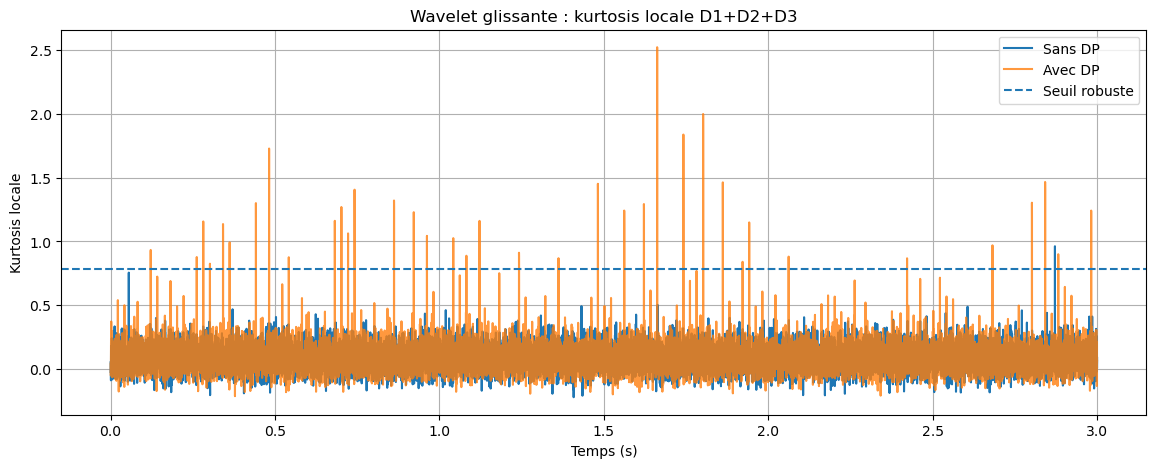


===== Conclusion Wavelet glissante =====
DP probable : le signal avec DP contient plus de fenêtres impulsionnelles.


In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

from scipy.stats import kurtosis


# =====================================================
# 1) Charger les données
# =====================================================

path_with = "/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_WithH_DP.npz"
path_none = "/home/yousef/Documents/testing_scripts/GEVernova/After_Aix/CAL2B_files/Time_NoneH_DP.npz"

data_with = np.load(path_with)
data_none = np.load(path_none)

x_with = np.asarray(data_with["ampl"], dtype=np.complex64).ravel()
x_none = np.asarray(data_none["ampl"], dtype=np.complex64).ravel()

FS = 12e6

env_with = np.abs(x_with)
env_none = np.abs(x_none)


# =====================================================
# 2) Normalisation robuste avec le signal sans DP
# =====================================================

mu_noise = np.median(env_none)
mad_noise = np.median(np.abs(env_none - mu_noise))
sigma_noise = 1.4826 * mad_noise + 1e-20

env_with_n = (env_with - mu_noise) / sigma_noise
env_none_n = (env_none - mu_noise) / sigma_noise


# =====================================================
# 3) Fonction : score wavelet local par fenêtre
# =====================================================

def sliding_wavelet_features(signal, fs, win_size=4096, step=2048, wavelet="db4", level=4):
    """
    Calcule des indicateurs wavelet sur des fenêtres courtes.
    
    Pour chaque fenêtre :
    - max_abs_D1_D2_D3 : amplitude max des détails rapides
    - energy_D1_D2_D3 : énergie des détails
    - kurt_D1_D2_D3 : impulsivité des détails
    """

    n = len(signal)

    times = []
    max_detail = []
    energy_detail = []
    kurt_detail = []

    for start in range(0, n - win_size, step):
        end = start + win_size
        w = signal[start:end]

        coeffs = pywt.wavedec(w, wavelet, level=level)

        # coeffs = [A4, D4, D3, D2, D1]
        # On prend D1, D2, D3
        D1 = coeffs[-1]
        D2 = coeffs[-2]
        D3 = coeffs[-3]

        details = np.concatenate([D1, D2, D3])

        times.append((start + win_size / 2) / fs)

        max_detail.append(np.max(np.abs(details)))
        energy_detail.append(np.sum(details ** 2))
        kurt_detail.append(kurtosis(details, fisher=True))

    return (
        np.array(times),
        np.array(max_detail),
        np.array(energy_detail),
        np.array(kurt_detail)
    )


# =====================================================
# 4) Calcul sur les deux signaux
# =====================================================

win_size = 4096
step = 2048
# win_size = 2048
# step = 1024
# win_size = 1024
# step = 512

t_none, max_none, energy_none_w, kurt_none_w = sliding_wavelet_features(
    env_none_n,
    FS,
    win_size=win_size,
    step=step,
    wavelet="db4",
    level=4
)

t_with, max_with, energy_with_w, kurt_with_w = sliding_wavelet_features(
    env_with_n,
    FS,
    win_size=win_size,
    step=step,
    wavelet="db4",
    level=4
)


# =====================================================
# 5) Seuils robustes appris sur le signal sans DP
# =====================================================

def robust_threshold(x, K=8):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    sigma = 1.4826 * mad + 1e-20
    return med + K * sigma, med, sigma


T_max, med_max, sig_max = robust_threshold(max_none, K=8)
T_energy, med_energy, sig_energy = robust_threshold(energy_none_w, K=8)
T_kurt, med_kurt, sig_kurt = robust_threshold(kurt_none_w, K=8)

print("Seuil max detail =", T_max)
print("Seuil energy detail =", T_energy)
print("Seuil kurtosis detail =", T_kurt)


# =====================================================
# 6) Détection des fenêtres suspectes
# =====================================================

suspect_none = (max_none > T_max) | (energy_none_w > T_energy) | (kurt_none_w > T_kurt)
suspect_with = (max_with > T_max) | (energy_with_w > T_energy) | (kurt_with_w > T_kurt)

print("\nNombre fenêtres suspectes sans DP :", np.sum(suspect_none))
print("Nombre fenêtres suspectes avec DP :", np.sum(suspect_with))

ratio_windows = np.sum(suspect_with) / max(np.sum(suspect_none), 1)
print("Ratio fenêtres suspectes avec/sans =", ratio_windows)


# =====================================================
# 7) Visualisation max coefficient wavelet
# =====================================================

plt.figure(figsize=(14, 5))
plt.plot(t_none, max_none, label="Sans DP")
plt.plot(t_with, max_with, label="Avec DP", alpha=0.8)
plt.axhline(T_max, linestyle="--", label="Seuil robuste")
plt.title("Wavelet glissante : max(|D1,D2,D3|)")
plt.xlabel("Temps (s)")
plt.ylabel("Max coefficient wavelet")
plt.grid(True)
plt.legend()
plt.show()


# =====================================================
# 8) Visualisation énergie locale
# =====================================================

plt.figure(figsize=(14, 5))
plt.plot(t_none, 10*np.log10(energy_none_w + 1e-20), label="Sans DP")
plt.plot(t_with, 10*np.log10(energy_with_w + 1e-20), label="Avec DP", alpha=0.8)
plt.axhline(10*np.log10(T_energy + 1e-20), linestyle="--", label="Seuil robuste")
plt.title("Wavelet glissante : énergie locale D1+D2+D3")
plt.xlabel("Temps (s)")
plt.ylabel("Énergie locale (dB)")
plt.grid(True)
plt.legend()
plt.show()


# =====================================================
# 9) Visualisation kurtosis locale
# =====================================================

plt.figure(figsize=(14, 5))
plt.plot(t_none, kurt_none_w, label="Sans DP")
plt.plot(t_with, kurt_with_w, label="Avec DP", alpha=0.8)
plt.axhline(T_kurt, linestyle="--", label="Seuil robuste")
plt.title("Wavelet glissante : kurtosis locale D1+D2+D3")
plt.xlabel("Temps (s)")
plt.ylabel("Kurtosis locale")
plt.grid(True)
plt.legend()
plt.show()


# =====================================================
# 10) Conclusion
# =====================================================

print("\n===== Conclusion Wavelet glissante =====")

if ratio_windows > 2 and np.sum(suspect_with) > 0:
    print("DP probable : le signal avec DP contient plus de fenêtres impulsionnelles.")
elif np.sum(suspect_with) > np.sum(suspect_none):
    print("DP possible : légère augmentation des fenêtres impulsionnelles.")
else:
    print("Pas de preuve forte avec cette configuration.")